In [2]:
# Libraries
import numpy as np 
import rasterio
from rasterio.mask import mask
import pandas as pd
import geopandas as gpd
from tqdm import tqdm  
from rasterio.plot import show
import matplotlib.pyplot as plt
#from rasterio.merge import merge

In [12]:
# Function to crop conus rasters to smaller spatial extents
def crop_raster(in_raster, out_raster, crop_object):
    with rasterio.open(in_raster) as src:
        print(f'crop_object crs = {in_raster} crs: {crop_object.crs == src.crs}')
        out_image, out_transform = mask(src, crop_object.geometry, crop = True)
        out_meta = src.meta.copy() # Copy src metadata

    out_meta.update({
        'driver':'Gtiff',
        'height':out_image.shape[1], # Height starts with shape[1]
        'width':out_image.shape[2], # Width starts with shape[2]
        'transform':out_transform
    })

    with rasterio.open(out_raster,'w',**out_meta) as dst:
        dst.write(out_image)

In [13]:
# Crop rasters to Washington, DC

## Washington, DC shp
dc = gpd.read_file('./data/DC_shp/Washington_DC_Boundary.shp')
dc = dc.to_crs('epsg:5070') # Reproject

## GSI suitability
gsi_suitability_conus = './data/final_outputs/model1_ahp_weights_ssp2_2025_RECLASSIFIED_2.tif'
gsi_suitability_dc = './data/little rasters/gsi_suitability_Washington_DC.tif'

crop_raster(in_raster = gsi_suitability_conus, 
            out_raster = gsi_suitability_dc, 
            crop_object = dc)

## Culex suitability
culex_suitability_conus = './data/mosquitoes/urban_culex_composite_reclassified_suitability_pip_quin.tif'
culex_suitability_dc = './data/little rasters/culex_suitability_Washington_DC.tif'
crop_raster(in_raster = culex_suitability_conus, 
            out_raster = culex_suitability_dc, 
            crop_object = dc)

crop_object crs = ./data/final_outputs/model1_ahp_weights_ssp2_2025_RECLASSIFIED_2.tif crs: True
crop_object crs = ./data/mosquitoes/urban_culex_composite_reclassified_suitability_pip_quin.tif crs: True


{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -10.0, 'width': 623, 'height': 748, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, 1610745.0,
       0.0, -30.0, 1936215.0), 'blockxsize': 623, 'blockysize': 6, 'tiled': False, 'interleave': 'band'}


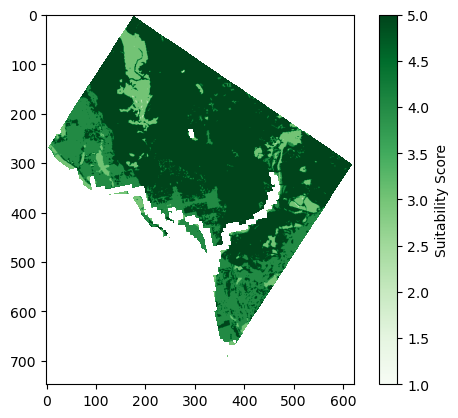

In [18]:
with rasterio.open(gsi_suitability_dc) as src:
    print(src.profile)
    arr = src.read(1, masked = True)
    plt.imshow(arr, cmap = 'Greens', vmin = 1, vmax = 5)
    plt.colorbar(label = 'Suitability Score')

{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -10.0, 'width': 623, 'height': 748, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]'), 'transform': Affine(30.0, 0.0, 1610745.0,
       0.0, -30.0, 1936215.0), 'blockxsize': 623, 'blockysize': 6, 'tiled': False, 'interleave': 'band'}


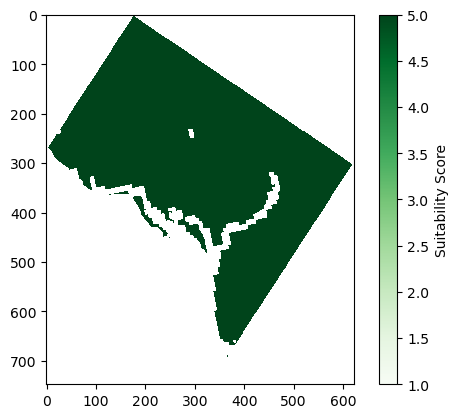

In [19]:
with rasterio.open(culex_suitability_dc) as src:
    print(src.profile)
    arr = src.read(1, masked = True)
    plt.imshow(arr, cmap = 'Greens', vmin = 1, vmax = 5)
    plt.colorbar(label = 'Suitability Score')

In [2]:
culex_dc = './data/little rasters/culex_suitability_Washington_DC.tif'
gsi_dc = './data/little rasters/gsi_suitability_Washington_DC.tif'

In [11]:
# % of cells highly suitable for GSI that are also highly suitable for Culex (CONUS)
gsi_highly_suitable = 0
highly_suitabile_BOTH = 0

gsi_suitability_conus = './data/final_outputs/model1_ahp_weights_ssp2_2025_RECLASSIFIED_2.tif'
culex_suitability_conus = './data/mosquitoes/urban_culex_composite_reclassified_suitability_pip_quin.tif'

with rasterio.open(gsi_suitability_conus) as gsi, rasterio.open(culex_suitability_conus) as culex:
    for ji, window in gsi.block_windows(1):
        gsi_data = gsi.read(1, window = window, masked = True)
        culex_data = culex.read(1, window = window, masked = True)

        combined_mask = gsi_data.mask | culex_data.mask
        gsi_data = np.ma.array(gsi_data.data, mask=combined_mask)
        culex_data = np.ma.array(culex_data.data, mask=combined_mask)
        
        gsi_highly_suitable += np.count_nonzero(gsi_data == 5) # Total number of cells highly suitable for GSI
        highly_suitabile_BOTH += np.count_nonzero((gsi_data == 5) & (culex_data == 5))

pct = highly_suitabile_BOTH / gsi_highly_suitable * 100
print(f'(Number of cells highly suitable for GSI: {gsi_highly_suitable}')
print(f'(Number of cells highly suitable for Culex & GSI: {highly_suitabile_BOTH}')
print(f'(Percent of cells highly suitable for GSI that are also highly suitable for Culex: {pct}')

(Number of cells highly suitable for GSI: 124628821
(Number of cells highly suitable for Culex & GSI: 74703490
(Percent of cells highly suitable for GSI that are also highly suitable for Culex: 59.9407820764027


In [10]:
# % of cells highly or moderately suitable for GSI that are also highly or moderately suitable for Culex (CONUS)
total_gsi_high_mod_suitable = 0
total_high_mod_suitable_BOTH = 0

gsi_suitability_conus = './data/final_outputs/model1_ahp_weights_ssp2_2025_RECLASSIFIED_2.tif'
culex_suitability_conus = './data/mosquitoes/urban_culex_composite_reclassified_suitability_pip_quin.tif'

with rasterio.open(gsi_suitability_conus) as gsi, rasterio.open(culex_suitability_conus) as culex:
    for ji, window in gsi.block_windows(1):
        gsi_data = gsi.read(1, window = window, masked = True)
        culex_data = culex.read(1, window = window, masked = True)

        combined_mask = gsi_data.mask | culex_data.mask
        gsi_data = np.ma.array(gsi_data.data, mask=combined_mask)
        culex_data = np.ma.array(culex_data.data, mask=combined_mask)

        gsi_high_mod = (gsi_data == 5) | (gsi_data == 4) # Cells highly or moderately suitable for GSI
        culex_high_mod = (culex_data == 5) | (culex_data == 4) # Cells highly or moderately suitable for Culex
        
        total_gsi_high_mod_suitable += np.count_nonzero(gsi_high_mod) # Total number of cells highly or moderately suitable for GSI
        total_high_mod_suitable_BOTH += np.count_nonzero(gsi_high_mod & culex_high_mod)

pct = total_high_mod_suitable_BOTH / total_gsi_high_mod_suitable * 100
print(f'(Number of cells highly or moderately suitable for GSI: {total_gsi_high_mod_suitable}')
print(f'(Number of cells highly suitable for Culex & GSI: {total_high_mod_suitable_BOTH}')
print(f'(Percent of cells highly suitable for GSI that are also highly suitable for Culex: {pct}')

(Number of cells highly or moderately suitable for GSI: 782463271
(Number of cells highly suitable for Culex & GSI: 432189415
(Percent of cells highly suitable for GSI that are also highly suitable for Culex: 55.23446671786336


In [37]:
culex_suitability_dc = './data/little rasters/culex_suitability_Washington_DC.tif'
with rasterio.open(culex_suitability_dc, 'r') as culex:
    arr1 = culex.read(1, masked = True)
    print(arr1[125:150, 300:325], '\n')

gsi_suitability_dc = './data/little rasters/gsi_suitability_Washington_DC.tif'
with rasterio.open(gsi_suitability_dc, 'r') as gsi:
    arr2 = gsi.read(1, masked = True)
    print(arr2[125:150, 300:325], '\n')



[[5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
 [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 

In [41]:
# Subtract present conditions from future conditions to calculate change
    # 0 = no change
    # positive values = increase in suitability
    # negative values = decrease in suitability 

gsi_suitability_dc = './data/little rasters/gsi_suitability_Washington_DC.tif' # current
culex_suitability_dc = './data/little rasters/culex_suitability_Washington_DC.tif' # present

test = './data/little rasters/change_detection_TEST2.tif'


with rasterio.open(gsi_suitability_dc) as src1:
    profile = src1.profile.copy()
    nodata = src1.nodata

    # Total number of blocks
    total_blocks = sum(1 for _ in src1.block_windows(1))
    print(f'Total blocks: {total_blocks}')
    
    with rasterio.open(culex_suitability_dc) as src2:

        with rasterio.open(test, 'w', **profile) as dst:

            for ji, window in tqdm(src1.block_windows(1), total = total_blocks, desc = 'Block window processing'):
                present = src1.read(1, window = window) # Read in culex data
                future = src2.read(1, window = window) # Read in GSI data

                diff = future - present # Difference btwn future and present conditions

                nodata_cells = (present == nodata) | (future == nodata) # Isolate nodata cells
                diff[nodata_cells] = nodata # Replace nodata cells with nodata value

                change = np.where(diff >0, 1,
                                  np.where(diff <0, -1, diff))
                change[nodata_cells] = nodata
                                

                dst.write(change, 1, window = window)

Total blocks: 125


Block window processing: 100%|██████████| 125/125 [00:00<00:00, 2118.37it/s]


In [42]:
test1 = './data/little rasters/change_detection_TEST.tif'
test2 = './data/little rasters/change_detection_TEST2.tif'


with rasterio.open(test1, 'r') as gsi:
    arr1 = gsi.read(1, masked = True)
    print(arr1[125:150, 300:325], '\n')

with rasterio.open(test2, 'r') as gsi:
    arr2 = gsi.read(1, masked = True)
    print(arr2[125:150, 300:325], '\n')

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 2 2 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 2 2 2 2 2 2 2 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 2 2 2 2 2 2 2 2 0 0 0 1 1 1 1 0 0 0 0 

In [ ]:
import rasterio
import numpy as np
from rasterio.transform import from_bounds

current_path = './data/gsi_current.tif'
future_path = './data/gsi_future.tif'
output_path = './data/gsi_change.tif'

with rasterio.open(current_path) as current_src, rasterio.open(future_path) as future_src:
    profile = current_src.profile.copy()
    profile.update(dtype=rasterio.uint8, nodata=255)

    with rasterio.open(output_path, 'w', **profile) as dst:
        for ji, window in current_src.block_windows(1):
            current_data = current_src.read(1, window=window, masked=True)
            future_data = future_src.read(1, window=window, masked=True)

            combined_mask = current_data.mask | future_data.mask

            # 0 = no change, 1 = changed
            result = np.where(current_data.data == future_data.data, 0, 1).astype(np.uint8)
            result[combined_mask] = 255  # nodata

            dst.write(result, 1, window=window)

print(f'Done. Output written to {output_path}')

In [6]:
# GSI raster
with rasterio.open(gsi_dc) as src:
    gsi = src.read(1, masked = True)

# Culex raster
with rasterio.open(culex_dc) as src:
    culex = src.read(1, masked = True)

# Cells highly suitable for gsi
gsi_highly_suitable = gsi == 5

# Cells highly suitable for both gsi and culex
highly_suitabile_BOTH = (gsi == 5) & (culex == 5)

# Percent highly suitable for both gsi & culex
pct = highly_suitabile_BOTH.sum() / gsi_highly_suitable.sum()

print(f'(Number of cells highly suitable for GSI: {highly_suitabile_BOTH.sum()}')
print(f'(Number of cells highly suitable for Culex: {gsi_highly_suitable.sum()}')
print(f'(Percent of cells highly suitable for GSI that are also highly suitable for Culex: {pct}')

(Number of cells highly suitable for GSI: 121506
(Number of cells highly suitable for Culex: 121506
(Percent of cells highly suitable for GSI that are also highly suitable for Culex: 1.0
